In [1]:
!uv pip install ultralytics roboflow opencv-python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow
from ultralytics.solutions import object_counter


Using Python 3.12.13 environment at: /usr
Resolved 70 packages in 779ms
Prepared 8 packages in 1.32s
Uninstalled 2 packages in 14ms
Installed 8 packages in 19ms
 + filetype==1.2.0
 - opencv-python-headless==5.0.0.93
 + opencv-python-headless==4.10.0.84
 + pi-heif==1.4.0
 + pillow-avif-plugin==1.6.0
 + roboflow==1.4.0
 - typer==0.26.8
 + typer==0.25.1
 + ultralytics==8.4.108
 + ultralytics-thop==2.1.1
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


1. OpenCV is used as it can open video files, edit frames and is optamised for speed
2. saves time, money and processing power and there is no need to train model
3. It is a tracking the same car for example across multiple frames and assigns a unique id until it is out of frame

Part 2

In [2]:
model = YOLO('yolo26n.pt')


1. A pretrained model means that the model has already been trained before even editing it, so that means and it knows how to differentiate between classes/objects which saves time and processing power
2. It contains large datasets and have been trained heavly so it will give a much better accuracy and precision score
3. Model class names like person and car are to differeniate objects we see it as names and the computer sees it as 1s and 0s

Part 3

In [3]:
video_path = '/content/car video.mp4'
import cv2
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

print(f"Frame Width: {width}")
print(f"Frame Height: {height}")
print(f"FPS: {fps}")



Frame Width: 640
Frame Height: 360
FPS: 29


In [4]:
# predict is for detection adn track gives id
# model.predict(video_path, save=True)
video = model.track(video_path, save=True)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 257ms
Prepared 1 package in 56ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/302) /content/car video.mp4: 384x640 2 persons, 6 cars, 54.2ms
video 1/1 (frame 2/

1. FPS is frames per second it shows how many frames are displayed in one second
2. To know the resolution of the output video after training
3. File might be corrupt so it will save time

Part 4

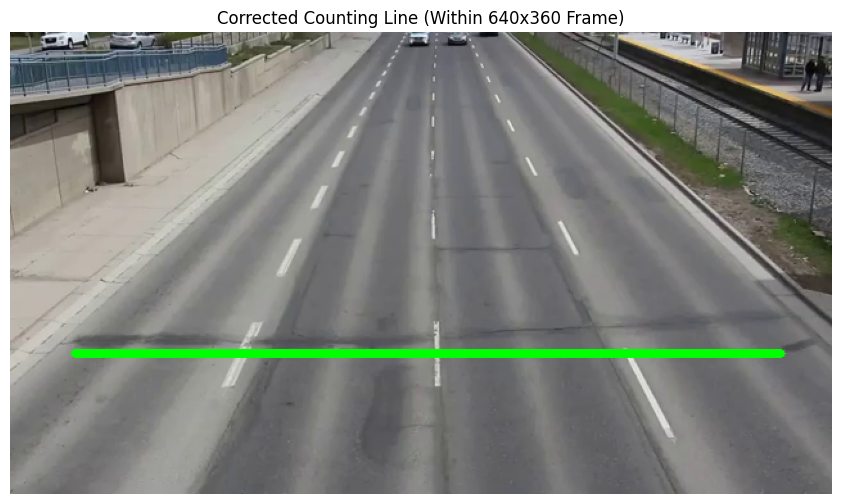

In [5]:
# Update global line_points to be within the 640x360 resolution
line_points = np.array([[50, 250], [600, 250]])

# Re-open video to grab a frame for visualization
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.line(frame, tuple(line_points[0]), tuple(line_points[1]), (0, 255, 0), 5)

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Corrected Counting Line (Within 640x360 Frame)")
    plt.axis('off')
    plt.show()
else:
    print("Could not read a frame from the video.")

1. A counting line is a line with two points whatever object crosses the line is counted.
2. It affects where objects are being counted when crossing the line wehther if it was vertical or diagonal or horizontal
3. Ensures accuracy which reduces false positives

Part 5

In [6]:
# i did with the centroid methods because the object count package was not working properly for me

from ultralytics import YOLO
import cv2
import numpy as np
import os
from IPython.display import Video, FileLink, display


model = YOLO('yolo26n.pt')
video_path = '/content/car video.mp4'

if not os.path.exists(video_path):
    print(f"Video not found: {video_path}")
else:
    # Open video
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video: {width}x{height}, {fps} FPS, {total_frames} frames")

    line_y = height // 2
    output_path = '/content/car_counted.mp4'
    out = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    previous_positions = {}
    counted_ids = set()
    in_count = 0
    out_count = 0

    print("Processing video...")
    frame_count = 0

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        frame_count += 1
        if frame_count % 50 == 0:
            print(f"   Frame {frame_count}/{total_frames}")

        results = model.track(
            frame,
            persist=True,
            conf=0.3,
            classes=[0, 2, 3, 5, 7]
            )

        cv2.line(frame, (50, line_y), (width-50, line_y), (0, 255, 0), 3)
        cv2.putText(frame, f"IN: {in_count}", (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2.putText(frame, f"OUT: {out_count}", (50, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        if results and results[0].boxes is not None:
            boxes = results[0].boxes
            if boxes.id is not None:
                track_ids = boxes.id.cpu().numpy().astype(int)
                centroids = []

                for i, box in enumerate(boxes.xyxy.cpu().numpy()):
                    x1, y1, x2, y2 = box.astype(int)
                    cx = (x1 + x2) // 2
                    cy = (y1 + y2) // 2
                    track_id = track_ids[i]
                    centroids.append((track_id, cx, cy))

                for track_id, cx, cy in centroids:
                    if track_id not in previous_positions:
                        previous_positions[track_id] = cy
                        continue

                    prev_y = previous_positions[track_id]

                    if prev_y < line_y and cy >= line_y:
                        if track_id not in counted_ids:
                            out_count += 1
                            counted_ids.add(track_id)
                            print(f"OUT: Object {track_id} left")
                    elif prev_y > line_y and cy <= line_y:
                        if track_id not in counted_ids:
                            in_count += 1
                            counted_ids.add(track_id)
                            print(f"IN: Object {track_id} entered")

                    previous_positions[track_id] = cy

                # Draw bounding boxes and IDs
                for i, box in enumerate(boxes.xyxy.cpu().numpy()):
                    x1, y1, x2, y2 = box.astype(int)
                    track_id = track_ids[i]
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, f"ID: {track_id}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        out.write(frame)

    # Cleanup
    cap.release()
    out.release()

    print(f"Frames processed: {frame_count}")
    print(f"IN Count: {in_count}")
    print(f"OUT Count: {out_count}")
    print(f"Output saved: {output_path}")



Video: 640x360, 29 FPS, 302 frames
🎥 Processing video...

0: 384x640 2 persons, 4 cars, 10.3ms
Speed: 1.0ms preprocess, 10.3ms inference, 50.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 4 cars, 10.1ms
Speed: 2.1ms preprocess, 10.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 5 cars, 10.1ms
Speed: 1.3ms preprocess, 10.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 3 cars, 10.3ms
Speed: 1.7ms preprocess, 10.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 4 cars, 9.7ms
Speed: 1.7ms preprocess, 9.7ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 3 cars, 9.3ms
Speed: 1.7ms preprocess, 9.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 3 cars, 10.6ms
Speed: 2.1ms preprocess, 10.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0:

1. Detection just finds the object while tracking finds and tracks the coordinates of the object while moving
2. It tells the tracker to remember the object between frames
3. Object IDs gives every unique object a permanent number, it keeps that ID across all frames until it leaves the video